In [21]:
import os
import json
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_design_matrix, plot_stat_map


In [22]:
# Subject
subject = "sub-003"

# base_dir = os.path.expanduser("~/neu502b/langloc_glm_work")
data_dir = "/usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer"
events_dir = "/usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer"
output_dir = "/usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer"

os.makedirs(output_dir, exist_ok=True)

bold_file = os.path.join(
    data_dir,
    f"{subject}_ses-01_task-langXlocal_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"
)

# bold_json = os.path.join(
#     data_dir,
#     f"{subject}_ses-01_task-langXlocal_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.json"
# )

mask_file = os.path.join(
    data_dir,
    f"{subject}_ses-01_task-langXlocal_run-1_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz"
)

confounds_file = os.path.join(
    data_dir,
    f"{subject}_ses-01_task-langXlocal_run-1_desc-confounds_timeseries.tsv"
)

events_file = os.path.join(
    events_dir,
    f"langloc_events.tsv"
)


In [23]:
# Load BOLD + TR
bold_img = nib.load(bold_file)
n_scans = bold_img.shape[-1]

# tr = None
# if os.path.exists(bold_json):
#     with open(bold_json, "r") as f:
#         meta = json.load(f)
#     tr = meta.get("RepetitionTime", None)

# if tr is None:
#     tr = bold_img.header.get_zooms()[-1]

print(f"Subject: {subject}")
print(f"BOLD shape: {bold_img.shape}")
print(f"n_scans: {n_scans}")
# print(f"TR: {tr}")

Subject: sub-003
BOLD shape: (78, 93, 78, 181)
n_scans: 181


In [24]:
# Load events
events_df = pd.read_csv(events_file, sep="\t")

required_cols = {"onset", "duration", "trial_type"}
missing = required_cols - set(events_df.columns)
if missing:
    raise ValueError(f"Events file missing columns: {missing}")

print("\nEvents preview:")
print(events_df.head())
print("\nTrial counts:")
print(events_df["trial_type"].value_counts())


Events preview:
   onset trial_type  duration
0     14          S         4
1     20          S         4
2     26          S         4
3     32          N         4
4     38          N         4

Trial counts:
trial_type
S    24
N    24
Name: count, dtype: int64


In [25]:
# Load confounds
confounds_df = pd.read_csv(confounds_file, sep="\t")

motion_cols = [
    "trans_x", "trans_y", "trans_z",
    "rot_x", "rot_y", "rot_z"
]

acompcor_cols = [c for c in confounds_df.columns if c.startswith("a_comp_cor")][:5]

selected_confounds = []
for c in motion_cols:
    if c in confounds_df.columns:
        selected_confounds.append(c)

for c in acompcor_cols:
    if c in confounds_df.columns:
        selected_confounds.append(c)

if "framewise_displacement" in confounds_df.columns:
    selected_confounds.append("framewise_displacement")

if not selected_confounds:
    raise ValueError("No confound columns were found.")

confounds_use = confounds_df[selected_confounds].copy()
confounds_use = confounds_use.fillna(0)

if len(confounds_use) != n_scans:
    raise ValueError(
        f"Confounds rows ({len(confounds_use)}) do not match n_scans ({n_scans})."
    )

print("\nConfounds used:")
print(confounds_use.columns.tolist())
print(confounds_use.shape)



Confounds used:
['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'framewise_displacement']
(181, 12)


In [26]:
# Fit GLM
glm = FirstLevelModel(
    t_r=2,
    mask_img=mask_file,
    noise_model="ar1",
    standardize=False,
    hrf_model="glover",
    drift_model="cosine",
    high_pass=1/128,
    smoothing_fwhm=5.0
)

glm = glm.fit(
    run_imgs=bold_file,
    events=events_df,
    confounds=confounds_use
)


In [27]:
# Extract + save design matrix
design_matrix = glm.design_matrices_[0]

print("\nDesign matrix columns:")
print(design_matrix.columns.tolist())

plt.figure(figsize=(14, 6))
plot_design_matrix(design_matrix)
plt.tight_layout()
design_png = os.path.join(output_dir, f"{subject}_design_matrix.png")
plt.savefig(design_png, dpi=200, bbox_inches="tight")
plt.close()

print(f"\nSaved design matrix PNG to:\n{design_png}")



Design matrix columns:
['N', 'S', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04', 'framewise_displacement', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'constant']


/tmp/ipykernel_109659/500136149.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



Saved design matrix PNG to:
/usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-003_design_matrix.png


<Figure size 1400x600 with 0 Axes>

In [28]:
# Compute contrasts
# Main localizer contrast
contrast_expr = "S - N"
t_map = glm.compute_contrast(contrast_expr, stat_type="t")
effect_map = glm.compute_contrast(contrast_expr, output_type="effect_size")

tmap_file = os.path.join(output_dir, f"{subject}_S_minus_N_tmap.nii.gz")
effect_file = os.path.join(output_dir, f"{subject}_S_minus_N_effect.nii.gz")

t_map.to_filename(tmap_file)
effect_map.to_filename(effect_file)

print(f"Saved t-map to:\n{tmap_file}")
print(f"Saved effect map to:\n{effect_file}")


Saved t-map to:
/usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-003_S_minus_N_tmap.nii.gz
Saved effect map to:
/usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-003_S_minus_N_effect.nii.gz


In [29]:
# Save visualization
display = plot_stat_map(
    t_map,
    threshold=3.1,
    display_mode="z",
    cut_coords=6,
    black_bg=False,
    title=f"{subject}: S > N"
)

stat_png = os.path.join(output_dir, f"{subject}_S_minus_N_tmap.png")
display.savefig(stat_png, dpi=200)
display.close()

print(f"Saved stat map PNG to:\n{stat_png}")
print("\nDone.")

Saved stat map PNG to:
/usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/sub-003_S_minus_N_tmap.png

Done.


In [30]:
# Define and make fROI masks, outputs both 1) who brain mask and 2) masks by frois 
# To run, change parameters in the DEFINE PARAMETERS
# Update LOGS
# 2024-06-07: Created by Selena She <jshe@mit.edu>

import numpy as np
import nibabel as nib
from os.path import join, exists, split
import os

###### DEFINE PARAMETERS ######

# defining global vars
LANG_PARCEL = '/usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer/allParcels-language-SN220.nii'
# LANG_FIRST_LEVEL = 'DefaultMNI_PlusStructural/results/firstlevel/langlocSN'
LANG_SPMT = f'{subject}_S_minus_N_effect.nii.gz'
EXPORT_PATH = f'/usr/people/zt4569/neu502b/neu502b_fmri/localizer_masks/{subject}'
ROI_MAPS = {1:'LH_IFGorb', 2:'LH_IFG', 3:'LH_MFG', 4:'LH_AntTemp', 5:'LH_PostTemp', 6:'LH_AnG', 7:'RH_IFGorb', 8:'RH_IFG', 9:'RH_MFG', 10:'RH_AntTemp', 11:'RH_PostTemp', 12:'RH_AnG'}

# defining task specific vars
first_level_dir = "/usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer"
print('fetching data from first level directory: ', first_level_dir)

###### DEFINE PARAMETERS ######


def check_unique(matrix):
    '''
    making sure masks are binary
    '''
    # Flatten the matrix to 1D array
    flattened_matrix = matrix.flatten()

    # Get unique values and their counts
    unique_values, counts = np.unique(flattened_matrix, return_counts=True)

    # Print the unique values and their counts
    for value, count in zip(unique_values, counts):
        print(f"Value: {value}, Count: {count}")


def get_top_10_thresholded_t_maps(lang_t_map, lang_parcel):
    '''
    function to threhold the t maps.

    for each parcel in the lang parcel:
        only keep the top 10% numerical values, set all else to 0

    returns the thresholded array
    '''
    # Counts of unique values in lang_parcel_img
    unique_values, counts = np.unique(lang_parcel, return_counts=True)
    print(f"Unique values in lang_parcel: {unique_values}")
    print(f"Counts of unique values: {counts}")


    # Initialize the output array for final t maps
    output_array_all = np.zeros_like(lang_t_map)
    
    # Process each unique value in lang parcel
    for value in unique_values:
        if value == 0.0:  # Skip the zero value
            continue
        
        output_array_a = np.zeros_like(lang_t_map)

        # Get the indices of the current value in lang parcel
        indices = np.where(lang_parcel_img == value)
        print(np.unique(indices[0]),np.unique(indices[1]),np.unique(indices[2]))
        print(lang_t_map.shape)
        print(lang_parcel_img.shape)
            
        try:
            corresponding_values = lang_t_map[indices]
        except Exception as e:
            print(f"Error processing parcel {value}: {e}")
            continue

        # Get the corresponding values in t maps
        
        # Find the threshold for the top 10% values
        threshold = np.percentile(corresponding_values, 90)
        
        # Get the mask for the top 10% values
        top_10_percent_mask = corresponding_values >= threshold

        # Set the top 10% values in the output array
        output_array_a[indices] = np.where(top_10_percent_mask, corresponding_values, 0)
        output_array_all[indices] = np.where(top_10_percent_mask, corresponding_values, 0)

        # saving individual froi maps
        save_maps_as_npy_and_nii(output_array_a, ROI_MAPS[value])
    
        # Sanity checks
        num_top_10_percent = np.sum(top_10_percent_mask)
        num_set_to_zero = len(corresponding_values) - num_top_10_percent
        
        print(f"Parcel number: {value}")
        print(f"Number of top 10% values kept: {num_top_10_percent}")
        print(f"Number of values set to 0: {num_set_to_zero}")
        print("#################")

    return output_array_all


def save_maps_as_npy_and_nii(thresholded_t_map, froi_region):
    '''
    save maps as both nii and npy files
    '''

    # binarize thresholded t maps
    thresholded_t_map[thresholded_t_map!=0] = 1
    
    export_path = f'{EXPORT_PATH}'
    export_filename = f'{export_path}/{froi_region}_fROI_mask_binary_top10percent'
    
    # if no dir make dir
    if not exists(export_path):
        os.makedirs(export_path)

    # saving np array to .npy file
    np.save(f'{export_filename}.npy', thresholded_t_map)

    # converting to nfti object and exporting as .nii
    AFFINE = np.array([
        [-2.,0.,0.,90.],
        [0.,2.,0.,-126.],
        [0.,0.,2.,-72.],
        [0.,0.,0.,1.],
        ])

    thresholded_t_maps_img = nib.Nifti1Image(thresholded_t_map.astype(np.int16), affine=AFFINE)
    nib.save(thresholded_t_maps_img, f'{export_filename}.nii')



# load lang t maps and parcel
lang_t_map_img = np.array(nib.load(f'{first_level_dir}/{LANG_SPMT}').dataobj)
lang_parcel_img = np.array(nib.load(LANG_PARCEL).dataobj)

from nilearn.image import resample_to_img
import nibabel as nib
import numpy as np

# load images
lang_parcel_nii = nib.load(LANG_PARCEL)                     # high-res parcel
lang_t_map_nii  = nib.load(f'{first_level_dir}/{LANG_SPMT}')  # low-res target

# resample parcel INTO the t-map/BOLD space
parcel_resampled_nii = resample_to_img(
    source_img=lang_parcel_nii,
    target_img=lang_t_map_nii,
    interpolation='nearest',   # important for label images
    force_resample=True
)

lang_parcel_img_resampled = np.asarray(parcel_resampled_nii.dataobj)

# or binary mask for all nonzero parcel voxels
all_parcel_mask = (lang_parcel_img_resampled > 0).astype(np.uint8)

    
# this steps iteratively exports all individual frois
thresholded_t_maps = get_top_10_thresholded_t_maps(lang_t_map_img, all_parcel_mask)

# now save the map with all frois
save_maps_as_npy_and_nii(thresholded_t_maps, 'ALL')
    


fetching data from first level directory:  /usr/people/zt4569/neu502b/neu502b_fmri/final_proj_localizer
Unique values in lang_parcel: [0 1]
Counts of unique values: [559581   6231]
[65 66 67 68 69 70 71 72] [72 73 74 75 76 77 78 79 80 81] [29 30 31 32 33 34 35 36 37 38]
(78, 93, 78)
(91, 109, 91)
Parcel number: 1
Number of top 10% values kept: 370
Number of values set to 0: 0
#################


/tmp/ipykernel_109659/1407263906.py:138: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lang_t_map_img = np.array(nib.load(f'{first_level_dir}/{LANG_SPMT}').dataobj)
/tmp/ipykernel_109659/1407263906.py:139: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lang_parcel_img = np.array(nib.load(LANG_PARCEL).dataobj)


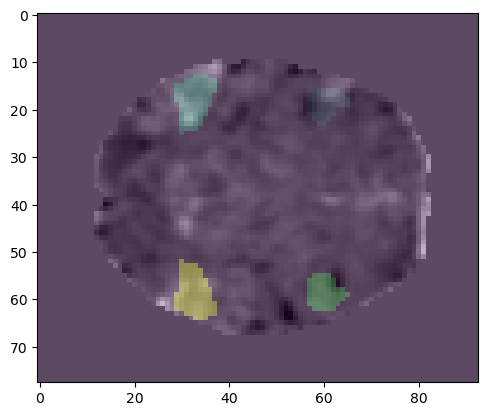

In [31]:
import matplotlib.pyplot as plt
plt.imshow(lang_t_map_img[:, :, lang_t_map_img.shape[2]//2], cmap='gray')
plt.imshow(lang_parcel_img_resampled[:, :, lang_parcel_img_resampled.shape[2]//2], alpha=0.3)
plt.show()

/usr/people/zt4569/miniconda3/envs/neu502b/lib/python3.12/site-packages/numpy/ma/core.py:2885: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


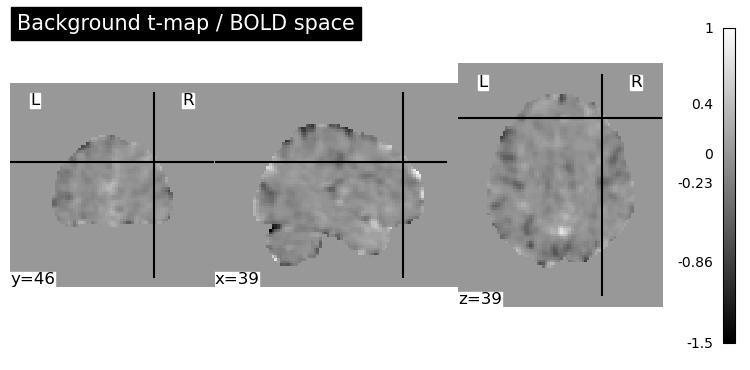

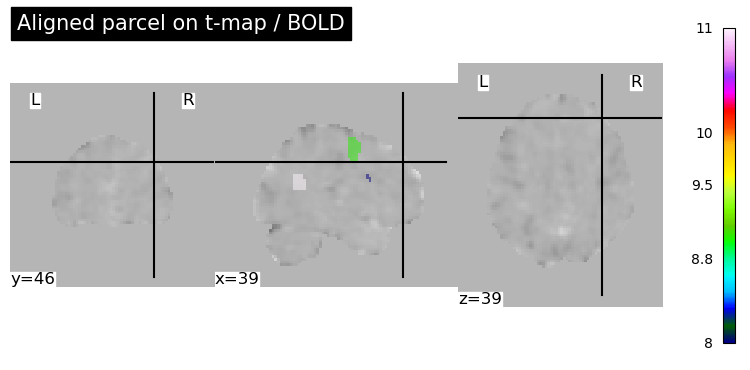

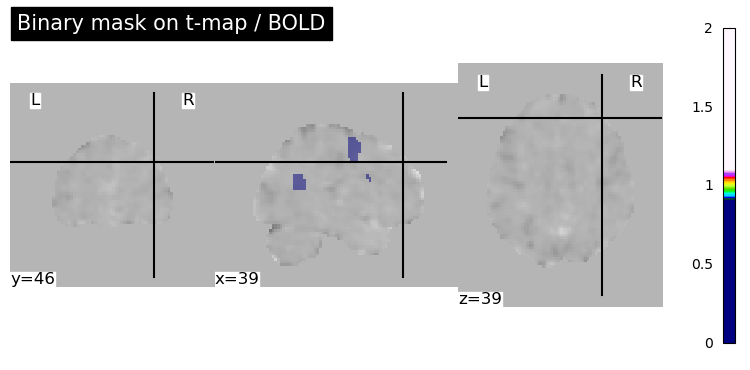

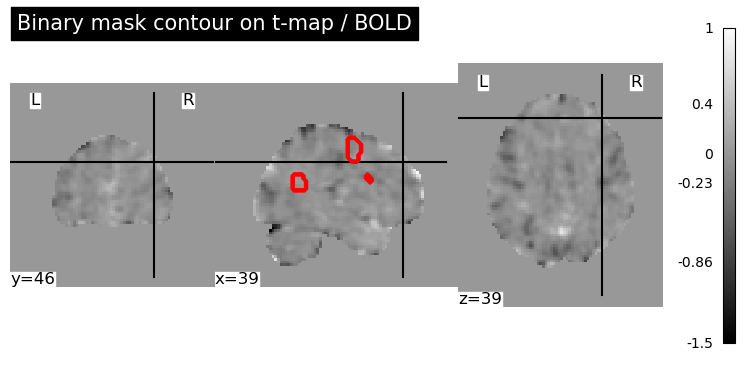

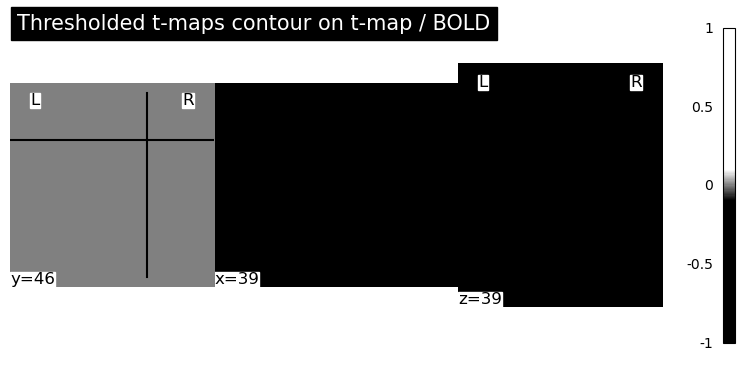

In [32]:
#| label: display-aligned-parcel-and-binary-mask

import matplotlib.pyplot as plt
from nilearn.image import new_img_like
from nilearn.plotting import plot_img, plot_roi

# make NIfTI images in the same space as the t map / bold data
parcel_resampled_img = new_img_like(lang_t_map_nii, lang_parcel_img_resampled)
all_parcel_mask_img = new_img_like(lang_t_map_nii, all_parcel_mask.astype(np.uint8))

shape = lang_t_map_nii.shape
cut_coords = (shape[0]//2, shape[1]//2, shape[2]//2)

# 1. background only
plot_img(
    lang_t_map_nii,
    title='Background t-map / BOLD space',
    display_mode='ortho',
    cut_coords=cut_coords
)

# 2. aligned parcel on background
plot_roi(
    roi_img=parcel_resampled_img,
    bg_img=lang_t_map_nii,
    title='Aligned parcel on t-map / BOLD',
    display_mode='ortho',
    cut_coords=cut_coords,
    alpha=0.5
)

# 3. binary mask on background
plot_roi(
    roi_img=all_parcel_mask_img,
    bg_img=lang_t_map_nii,
    title='Binary mask on t-map / BOLD',
    display_mode='ortho',
    cut_coords=cut_coords,
    alpha=0.5
)

# 4. contour check
display = plot_img(
    lang_t_map_nii,
    title='Binary mask contour on t-map / BOLD',
    display_mode='ortho',
    cut_coords=cut_coords,
    black_bg=False
)
display.add_contours(all_parcel_mask_img, colors='r', linewidths=1.5)


processed_mask = nib.load(f'{EXPORT_PATH}/ALL_fROI_mask_binary_top10percent.nii')
# plot countour of thresholded_t_maps
display = plot_img(
    processed_mask,
    title='Thresholded t-maps contour on t-map / BOLD',
    display_mode='ortho',
    cut_coords=cut_coords,
    black_bg=False
)
    
plt.show()


mask shape: (78, 93, 78)
unique values: [0. 1.]


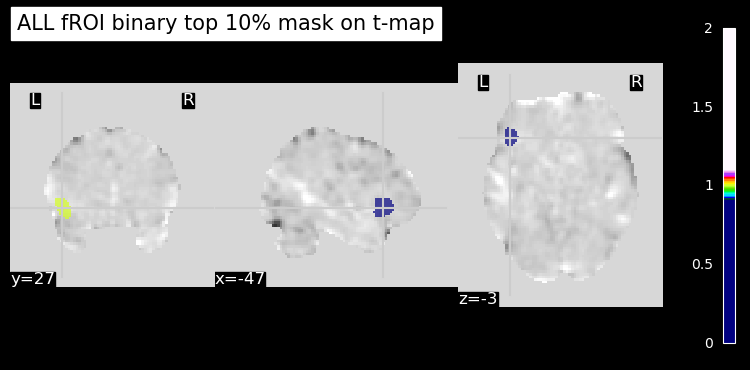

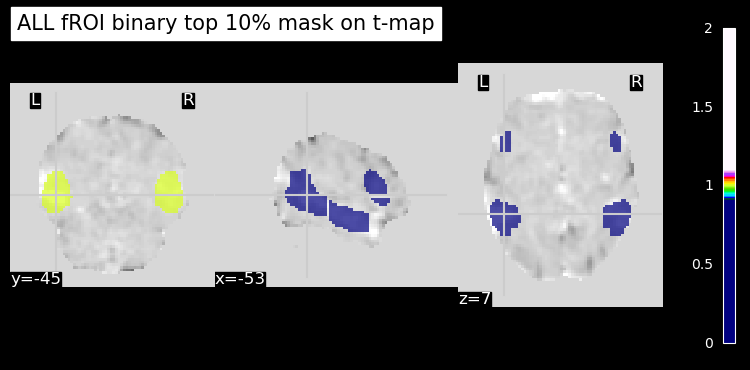

In [34]:
#| label: plot-saved-all-froi-binary-mask

import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.plotting import plot_img, plot_roi

# load the saved binary mask
all_froi_mask_nii = nib.load(f'{EXPORT_PATH}/ALL_fROI_mask_binary_top10percent.nii')

# quick sanity check
print("mask shape:", all_froi_mask_nii.shape)
print("unique values:", np.unique(all_froi_mask_nii.get_fdata()))


# binary mask overlaid on t-map
plot_roi(
    roi_img=all_froi_mask_nii,
    bg_img=lang_t_map_nii,
    title='ALL fROI binary top 10% mask on t-map',
    display_mode='ortho',
    cut_coords=None,
    black_bg=True,
    dim=-0.5,
    alpha=0.7
)

plot_roi(
    roi_img=all_parcel_mask_img,
    bg_img=lang_t_map_nii,
    title='ALL fROI binary top 10% mask on t-map',
    display_mode='ortho',
    cut_coords=None,
    black_bg=True,
    dim=-0.5,
    alpha=0.7
)
